# Capstone Project

## Superconducting quantum circuits at the surface code threshold for fault tolerance

**Author : Murat Can Sarihan, Google Quantum AI**

**References**

1. Barends, R. et al. Coherent Josephson Qubit Suitable for Scalable Quantum Integrated Circuits. Phys Rev Lett 111, 080502 (2013).
2. Barends, R. et al. Superconducting quantum circuits at the surface code threshold for fault tolerance. Nature 508, 500–503 (2014).
  

In this task, we will design one of the important devices in the history of superconducting quantum computing. In Barends et al. (2014), John Martinis and his team, which will build the foundations of Google Quantum AI lab shortly after, demonstrated a full set of 1Q and 2Q gates with fidelities above the fault-tolerance threshold required for surface code error correction. The result made quantum error correction with surface codes is not only a proposal but a serious possibility, which is demonstrated later.

The team achieved an average single-qubit gate fidelity of 99.92% and a two-qubit gate fidelity of up to 99.4% by designing a 5-qubit linear array quantum processor, with tunable transmons (Xmon) and fixed coupling.

During this task, we will attempt to build the same device that enabled the later advancements. We will be using the circuit elements we designed during the workshop, and integrate to create the device given in Figure 1.

![Architecture. (a) Optical image of the integrated Josephson quantum processor, consisting of Al (dark) on sapphire (light). The five cross-shaped devices are the Xmon variant of the transmon qubit13 , labelled Q0 − Q4 , placed in a linear array. To the left of the qubits are five meandering coplanar waveguide resonators used for individual state readout. Control wiring is brought in from the contact pads at the edge of the chip, ending at the right of the qubits. (b) Circuit diagram. Our architecture employs direct, nearestneighbour coupling of the qubits (red/orange), made possible by the nodal connectivity of the Xmon qubit. Using a single readout line, each qubit can be measured using frequency-domain multiplexing (blue). Individual qubits are driven through capacitively-coupled microwave control lines (XY), and frequency control is achieved through inductively-coupled dc lines (Z) (purple). (c) Schematic representation of an entangling operation using a controlled-Z gate with unitary representation UCZ : (I) Qubits at rest, at distinct frequencies with minimal interaction. (II) When brought near resonance, the state-dependent frequency shift brings about a rotation conditional on the qubit states. (III) Qubits are returned to their rest frequency.](../../assets/1.jpg)

**Figure 1: Architecture**. (a) Optical image of the integrated Josephson quantum processor, consisting of Al (dark) on sapphire (light). The five cross-shaped devices are the Xmon variant of the transmon qubit13 , labelled Q0 − Q4 , placed in a linear array. To the left of the qubits are five meandering coplanar waveguide resonators used for individual state readout. Control wiring is brought in from the contact pads at the edge of the chip, ending at the right of the qubits. (b) Circuit diagram. Our architecture employs direct, nearestneighbour coupling of the qubits (red/orange), made possible by the nodal connectivity of the Xmon qubit. Using a single readout line, each qubit can be measured using frequency-domain multiplexing (blue). Individual qubits are driven through capacitively-coupled microwave control lines (XY), and frequency control is achieved through inductively-coupled dc lines (Z) (purple). (c) Schematic representation of an entangling operation using a controlled-Z gate with unitary representation UCZ : (I) Qubits at rest, at distinct frequencies with minimal interaction. (II) When brought near resonance, the state-dependent frequency shift brings about a rotation conditional on the qubit states. (III) Qubits are returned to their rest frequency.

The processor has five qubits in a 1-D chain with maximum qubit frequency alternating between 5.8 GHz and 5 GHz approximately. The average nonlinearity, eta, of the qubits are around 215 MHz, while the coupling strength between two neighboring qubits are 30 MHz at 4.7 GHz. The qubits are apart from each other, enough to have 1.3 MHz next-nearest neighbour coupling strength.

# Solution - 5-Qubit Josephson Processor Layout

In this section, we implement the layout design for the 5-qubit linear transmon processor. We place the qubits horizontally, couple them to a single readout feedline via meandered resonators (frequency-staggered), and route the XY and Z control lines to the bottom edge of the chip.

In [38]:
%load_ext autoreload
%autoreload 2
%config IPCompleter.greedy = True
%matplotlib inline
%config Completer.use_jedi = False
%config InlineBackend.figure_format = 'svg'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Setup and Environment Initialization

Set the design to headless mode and initialize `DesignPlanar` with a substrate size of $6.0\,\text{mm} \times 6.0\,\text{mm}$.

In [39]:
import os
os.environ['QISKIT_METAL_HEADLESS'] = 'True'

import numpy as np


import qiskit_metal as metal
from qiskit_metal import designs, Dict
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross
from qiskit_metal.qlibrary.qubits.transmon_cross_fl import TransmonCrossFL
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.framed_path import RouteFramed
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.lumped.cap_n_interdigital import CapNInterdigital

import matplotlib.pyplot as plt
from qiskit_metal.renderers.renderer_mpl.mpl_renderer import QMplRenderer

# Instantiate Design
design = designs.DesignPlanar()
design.chips.main.size.size_x = '6.0mm'
design.chips.main.size.size_y = '6.0mm'

print("Headless design environment initialized with a 6x6 mm substrate!")


Headless design environment initialized with a 6x6 mm substrate!


## 2. Placer Qubits (Q0 to Q4)

We place 5 `TransmonCross` qubits horizontally with a pitch of $1.5\,\text{mm}$ along the $x$-axis. This close proximity creates nearest-neighbor capacitive coupling between the arms of the cross shape islands.

Each qubit is configured with three ports:
- `readout` (North arm, location `90`)
- `XY` (West arm, location `0`)
- `Z` (South arm, location `270`)

In [40]:
design.delete_all_components()
design.overwrite_enabled = True
qubit_pitch = 0.45  # mm pitch
qubits = []
xy_pads = []
for i in range(5):
    x_pos = (i - 2) * qubit_pitch
    q = TransmonCrossFL(design, f'Q{i}', options=dict(
        pos_x=f'{x_pos}mm',
        pos_y='0.0mm',
        orientation='0',
        cross_width='30um',
        cross_length='190um',
        cross_gap='50um',
        make_fl =True,
        fl_options = dict(
            t_gap='3um', 
            t_inductive_gap='3um', 
            t_offset='0um', 
            t_top='15um', 
            t_width='5um',
        ),
        connection_pads=dict(
            readout = dict(
                connector_type='0', 
                claw_length='40um', 
                ground_spacing='5um', 
                claw_width='10um', 
                claw_gap='6um', 
                connector_location='90' # North arm
            ),
        )
    ))
    qubits.append(q)

# 1. Place manual XY coupling pads (orientation = 90)

    xy_pad = OpenToGround(design, f'XY_pad_{i}', options=dict(
        pos_x=f'{x_pos - 0.1}mm',
        pos_y='-0.18mm',
        orientation='90',
        width='10um',
        gap='6um',
        termination_gap='6um'
    ))
    xy_pads.append(xy_pad)

print("XY pads placed!")
print("Placed qubits Q0, Q1, Q2, Q3, Q4!")

XY pads placed!
Placed qubits Q0, Q1, Q2, Q3, Q4!


In [41]:
xy_pads

[name:    XY_pad_0
 class:   OpenToGround          
 options: 
   'pos_x'             : '-1.0mm',                     
   'pos_y'             : '-0.18mm',                    
   'orientation'       : '90',                         
   'chip'              : 'main',                       
   'layer'             : '1',                          
   'width'             : '10um',                       
   'gap'               : '6um',                        
   'termination_gap'   : '6um',                        
 module:  qiskit_metal.qlibrary.terminations.open_to_ground
 id:      2,
 name:    XY_pad_1
 class:   OpenToGround          
 options: 
   'pos_x'             : '-0.55mm',                    
   'pos_y'             : '-0.18mm',                    
   'orientation'       : '90',                         
   'chip'              : 'main',                       
   'layer'             : '1',                          
   'width'             : '10um',                       
   'gap'         

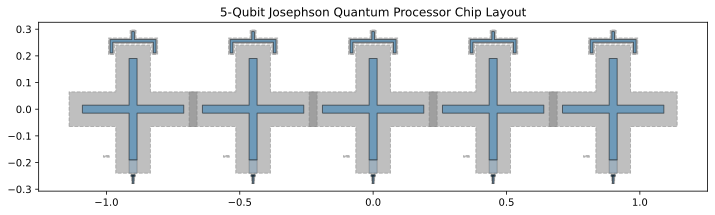

In [42]:
fig, ax = plt.subplots(figsize=(12, 12))
renderer = QMplRenderer(None, design, design.logger)
renderer.render(ax)

ax.autoscale()
ax.set_aspect('equal')
plt.title("5-Qubit Josephson Quantum Processor Chip Layout")
plt.show()

## 3. Readout Multiplexed Feedline

We place a single readout waveguide across the top ($y = 3.0\,\text{mm}$) of the chip. Along this feedline, we place 5 `CoupledLineTee` couplers aligned with the $x$-coordinates of the qubits. Two wirebond launchpads at the outer edges of the chip terminate the feedline, and straight CPW segments connect everything together.

In [146]:
# Let's track the length of Purcell filter starting from directional couplers.
total_purcell_length_mm = 0
# 1. Place CoupledLineTee couplers at y = 1.5 mm
couplers = []
for i in range(5):
    x_pos = (i - 2) * qubit_pitch
    clt = CoupledLineTee(design, f'CLT{i}', options=dict(
        pos_x=f'{x_pos}mm',
        pos_y='1.5mm',
        orientation='0',
        coupling_length='200um',
        coupling_space='4um'
    ))
    couplers.append(clt)
    total_purcell_length_mm += 0.2

# 2. Place Launchpads on all 4 sides (centered and 1.5 mm apart)
# Left side
lp_w1 = LaunchpadWirebond(design, 'LP_W1', options=dict(pos_x='-2.8mm', pos_y='-1.5mm', orientation='0'))
lp_w2 = LaunchpadWirebond(design, 'LP_W2', options=dict(pos_x='-2.8mm', pos_y='0.0mm', orientation='0'))
lp_w3 = LaunchpadWirebond(design, 'LP_W3', options=dict(pos_x='-2.8mm', pos_y='1.5mm', orientation='0'))

# Right side
lp_e1 = LaunchpadWirebond(design, 'LP_E1', options=dict(pos_x='2.8mm', pos_y='-1.5mm', orientation='180'))
lp_e2 = LaunchpadWirebond(design, 'LP_E2', options=dict(pos_x='2.8mm', pos_y='0.0mm', orientation='180'))
lp_e3 = LaunchpadWirebond(design, 'LP_E3', options=dict(pos_x='2.8mm', pos_y='1.5mm', orientation='180'))

# Bottom side
lp_s1 = LaunchpadWirebond(design, 'LP_S1', options=dict(pos_x='-1.5mm', pos_y='-2.8mm', orientation='90'))
lp_s2 = LaunchpadWirebond(design, 'LP_S2', options=dict(pos_x='0.0mm', pos_y='-2.8mm', orientation='90'))
lp_s3 = LaunchpadWirebond(design, 'LP_S3', options=dict(pos_x='1.5mm', pos_y='-2.8mm', orientation='90'))

# Top side
lp_n1 = LaunchpadWirebond(design, 'LP_N1', options=dict(pos_x='-1.5mm', pos_y='2.8mm', orientation='270'))
lp_n2 = LaunchpadWirebond(design, 'LP_N2', options=dict(pos_x='0.0mm', pos_y='2.8mm', orientation='270'))
lp_n3 = LaunchpadWirebond(design, 'LP_N3', options=dict(pos_x='1.5mm', pos_y='2.8mm', orientation='270'))

# 3. Place CapNInterdigital components for the feedline (length ~ 9mm)
cap_in = CapNInterdigital(design, 'Cap_input', options=dict(pos_x='-2.4mm', pos_y='1.5mm', orientation='270'))
cap_out = CapNInterdigital(design, 'Cap_output', options=dict(pos_x='-1mm', pos_y='2.1mm', orientation='90'))

print("Placed all launchpads and CapNInterdigital components!")

# 4. Connect readout feedline (bus waveguide)
# Connect LP_W3 to Cap_input
RouteStraight(design, 'Feed_in_lp', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='LP_W3', pin='tie'),
        end_pin=dict(component='Cap_input', pin='south_end')
    )
))

# Connect Cap_input to CLT0
purcell_left = RouteStraight(design, 'Feed_in_clt', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='Cap_input', pin='north_end'),
        end_pin=dict(component='CLT0', pin='prime_start')
    )
))
total_purcell_length_mm += purcell_left.length
for i in range(4):
    feed_i =  RouteStraight(design, f'Feed_mid_{i}', options=dict(
        pin_inputs=dict(
            start_pin=dict(component=f'CLT{i}', pin='prime_end'),
            end_pin=dict(component=f'CLT{i+1}', pin='prime_start')
          )
    ))
    total_purcell_length_mm += feed_i.length
# Connect CLT4 to Cap_output via bend and straight
purcell_right = RouteAnchors(design, 'Feed_out_clt', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='CLT4', pin='prime_end'),
        end_pin=dict(component='Cap_output', pin='north_end')
    ),

    anchors=Dict({0: (1.7, 1.5), 1: (1.7,1.8), 2: (-2.4, 1.8), }),
    fillet='100um',
    advanced=Dict(avoid_collision=False)
))
total_purcell_length_mm += purcell_right.length
# Connect Cap_output to LP_N1
RouteAnchors(design, 'Feed_out_lp', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='Cap_output', pin='south_end'),
        end_pin=dict(component='LP_N1', pin='tie')
    ),
    lead = Dict(start_straight = '200um',end_straight='100um'),
    # anchors=Dict({0: (-1.4, 2.1), 1: (-1, 2.5), 2: (-1, 2.5)}),
    fillet='20um',
    advanced=Dict(avoid_collision=False)
))

print("Multiplexed readout feedline routed successfully!")
print(f"Total Purcell filter length : {total_purcell_length_mm:.3f} mm")

Placed all launchpads and CapNInterdigital components!
Multiplexed readout feedline routed successfully!
Total Purcell filter length : 9.028 mm


## 4. Staggered Readout Resonators

We route the 5 meandered CPW resonators. To allow frequency-domain multiplexing, the length of each resonator is staggered (from $5.8\,\text{mm}$ to $6.6\,\text{mm}$ in steps of $0.2\,\text{mm}$), resulting in distinct resonance frequencies.

In [147]:
# Define 5 staggered total lengths for frequency-multiplexed readout
resonator_lengths = ['4.41mm', '4.45mm', '4.49mm', '4.53mm', '4.57mm']

for i in range(5):
    RouteMeander(design, f'ReadoutRes{i}', options=dict(
        pin_inputs=dict(
            start_pin=dict(component=f'Q{i}', pin='readout'),
            end_pin=dict(component=f'CLT{i}', pin='second_end')
        ),
        total_length=resonator_lengths[i],
        fillet='20um',
        lead=dict(
            start_straight='150um',
            end_straight='150um'
        ),
        meander=dict(
            spacing='50um',
            asymmetry='0um'
        )
    ))

print("Staggered meander resonators routed successfully!")

02:42PM 13s WARNING [check_lengths]: For path table, component=ReadoutRes0, key=trace has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.
02:42PM 13s WARNING [check_lengths]: For path table, component=ReadoutRes0, key=cut has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.
02:42PM 13s WARNING [check_lengths]: For path table, component=ReadoutRes1, key=trace has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.
02:42PM 13s WARNING [check_lengths]: For path table, component=ReadoutRes1, key=cut has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.
02:42PM 13s WARNING [check_lengths]: For path table, component=ReadoutRes2, key=trace has short segments that could cause issues with fillet. Values in (29-30)  are index(es) in shapely geometry.
02:42PM 13s WARNING [che

Staggered meander resonators routed successfully!


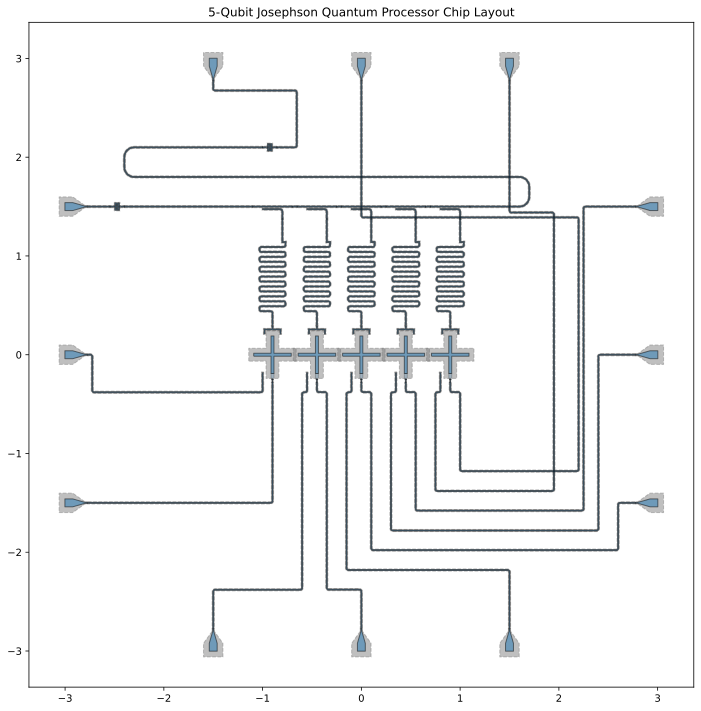

In [148]:
fig, ax = plt.subplots(figsize=(12, 12))
renderer = QMplRenderer(None, design, design.logger)
renderer.render(ax)

ax.autoscale()
ax.set_aspect('equal')
plt.title("5-Qubit Josephson Quantum Processor Chip Layout")
plt.show()

## 5. Routing XY & Z Control Lines

We place three launchpads on each of the four sides of the 6.0 mm x 6.0 mm chip, centered and 1.5 mm apart from each other. The multiplexed feedline has a length of ~10 mm and is terminated by CapNInterdigital components. The feedline input connects to LP_W3 and the output connects to LP_N1. The remaining 10 launchpads are used for the XY and Z control lines of the 5 qubits. We route the lines using `RoutePathfinder` with zero anchors, which uses an A* pathfinding algorithm to automatically compute planar, non-crossing routes around all obstacles.


In [173]:

control_routes = [
    # Q0 XY -> LP_W2
    ('XY_pad_0', 'open', 'LP_W2', 'tie', 'XY_Line_0', Dict({})),
    # Q0 Z -> LP_W1
    ('Q0', 'flux_line', 'LP_W1', 'tie', 'Z_Line_0', Dict({})),
    # Q1 XY -> LP_S1
    ('XY_pad_1', 'open', 'LP_S1', 'tie', 'XY_Line_1', Dict({
        0: ['R', '50um'],
        1: ['L', '2000um'],
        2: ['R', '200um']

    })),
    # Q1 Z -> LP_E3
    ('Q1', 'flux_line', 'LP_S2', 'tie', 'Z_Line_1', Dict({
        0: ['L', '100um'],
        1: ['R', '2000um'],
        2:['L', '200um'],
        # 3:['R', '200um'],
    })),
    # Q2 XY -> LP_S2
    ('XY_pad_2', 'open', 'LP_S3', 'tie', 'XY_Line_2', Dict({
        0: ['R', '50um'],
        1: ['L', '1800um'],
        2: ['L', '500um']
    })),
    # Q2 Z -> LP_N2
    ('Q2', 'flux_line', 'LP_E1', 'tie', 'Z_Line_2', Dict({
       0: ['L', '100um'],
       1: ['R', '1600um'],
       2: ['L', '2500um'],
       3: ['L','100um'],
    })),
    # Q3 XY -> LP_S3
    ('XY_pad_3', 'open', 'LP_E2', 'tie', 'XY_Line_3', Dict({
        0: ['R', '50um'],
        1: ['L', '1400um'],
        2: ['L', '2100um'],
        3: ['L', '1200um'],
    })),
    # Q3 Z -> LP_N3
    ('Q3', 'flux_line', 'LP_E3', 'tie', 'Z_Line_3', Dict({
        0: ['L', '100um'],
        1: ['R', '1200um'],
        2: ['L', '1700um'],
        3: ['L', '800um']
    })),
    # Q4 XY -> LP_E2
    ('XY_pad_4', 'open', 'LP_N3', 'tie', 'XY_Line_4', Dict({
        0: ['R', '50um'],
        1: ['L', '1000um'],
        2: ['L', '1350um'],
        3: ['L', '3700um'],
        4: ['L', '400um'],
    })),
    # Q4 Z -> LP_E1
    ('Q4', 'flux_line', 'LP_N2', 'tie', 'Z_Line_4', Dict({
        0: ['L', '100um'],
        1: ['R', '800um'],
        2: ['L', '950um'],
        3: ['L', '3300um'],
        4: ['L', '400um'],
    })),
]

for start_comp, start_pin, end_comp, end_pin, route_name, turtle_steps in control_routes:
    route_options = dict(
        pin_inputs=dict(
            start_pin=dict(component=start_comp, pin=start_pin),
            end_pin=dict(component=end_comp, pin=end_pin)
        ),
        lead=dict(
            start_straight='100um',
            end_straight='50um',
            start_jogged_extension = turtle_steps,

        ),
        
        fillet='20um',
        step_size='0.05mm',

    )
    if "XY" in route_name:
        route_options['lead']['start_straight'] = '200um'
        
    RouteFramed(design, route_name, options=route_options)

print("XY and Z control lines successfully routed!")


XY and Z control lines successfully routed!


## 6. Plotting the Completed Chip Layout

Let's render our finalized chip layout inline using Matplotlib renderer.

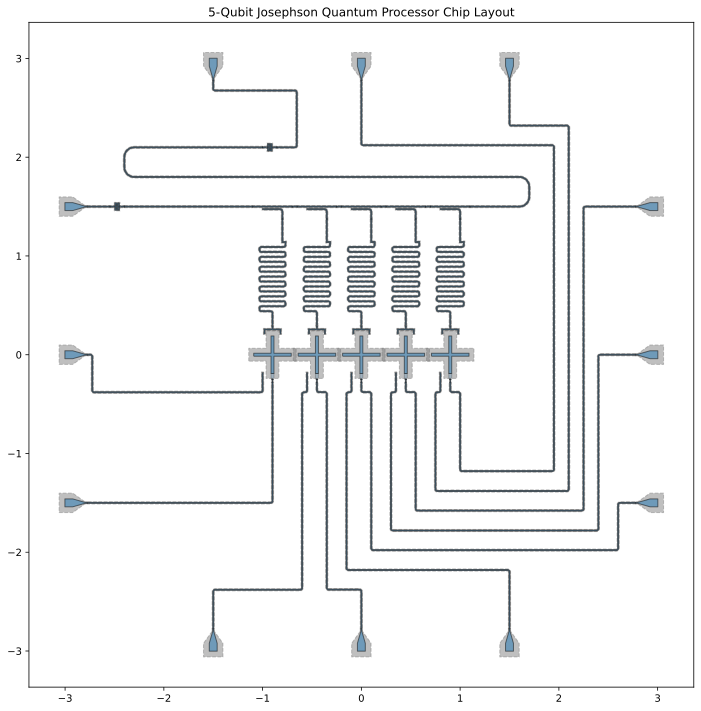

In [174]:
fig, ax = plt.subplots(figsize=(12, 12))
renderer = QMplRenderer(None, design, design.logger)
renderer.render(ax)

ax.autoscale()
ax.set_aspect('equal')
plt.title("5-Qubit Josephson Quantum Processor Chip Layout")
plt.show()

## 7. Exporting to GDSII

We export the final mask layout to GDSII format.

In [48]:
gds_renderer = design.renderers.gds
gds_filename = 'barends_5qubit_processor.gds'
gds_renderer.export_to_gds(gds_filename)

print(f"Layout exported to GDSII: {gds_filename}!")

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df_copy.append(orig_row, ignore_index=False)

  df_copy = df

Layout exported to GDSII: barends_5qubit_processor.gds!
